In [1]:
# --! include root folder into PYTHONPATH ---------------------------------!

import os
import sys

thisdir = os.getcwd()
rootdir = os.path.abspath(os.path.join(thisdir, '..', '..'))
sys.path.append(rootdir)

In [2]:
# --! import Python libraries and KIND framework files -------------------!

import torch
from matplotlib import pyplot as plt

import kind
import utils_plot

# Training our KIND framework on synthetic data

### Stationary dataset


inf >> dataset parameters:

 dataset  batches  timeseries length channels
--------  -------  ----------------- --------
   train     3500                200        1
   valid     1000                200        1
    test      500                200        1



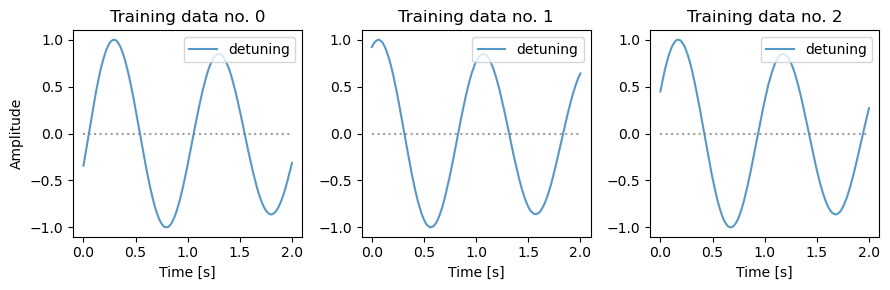

In [3]:
# --!------------------------------------------------------!
# --! display stationary dataset

datadir               = '../../data/kalman/train_sim_sta'
timeseries_ndim       = 1
timeseries_nsample    = 200
timestep              = 0.01

# --! subtimeseries give us additional flexibility by allowing to work with subportions
# --! of original sampled timeseries
subtimeseries_nsample = timeseries_nsample

utils_plot.plot_dataset(datadir, timeseries_nsample, timestep)

### Transient dataset


inf >> dataset parameters:

 dataset  batches  timeseries length channels
--------  -------  ----------------- --------
   train     3500                200        1
   valid     1000                200        1
    test      500                200        1



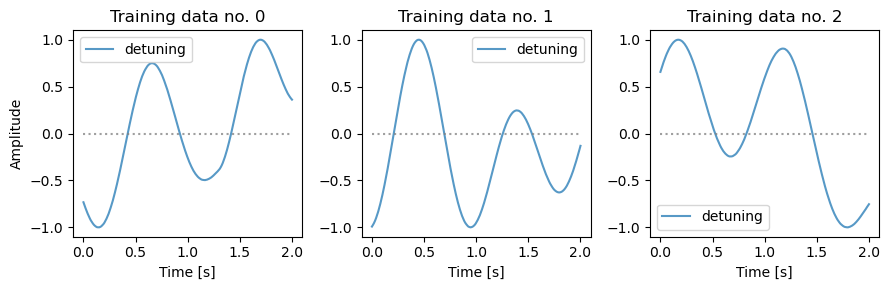

In [4]:
# --!------------------------------------------------------!
# --! display transient dataset

datadir               = '../../data/kalman/train_sim_dyn'
timeseries_ndim       = 1
timeseries_nsample    = 200
timestep              = 0.01

# --! subtimeseries give us additional flexibility by allowing to work with subportions
# --! of original sampled timeseries
subtimeseries_nsample = timeseries_nsample

utils_plot.plot_dataset(datadir, timeseries_nsample, timestep)

### Mix of stationary and transient datasets


inf >> dataset parameters:

 dataset  batches  timeseries length channels
--------  -------  ----------------- --------
   train     3500                200        1
   valid     1000                200        1
    test      500                200        1



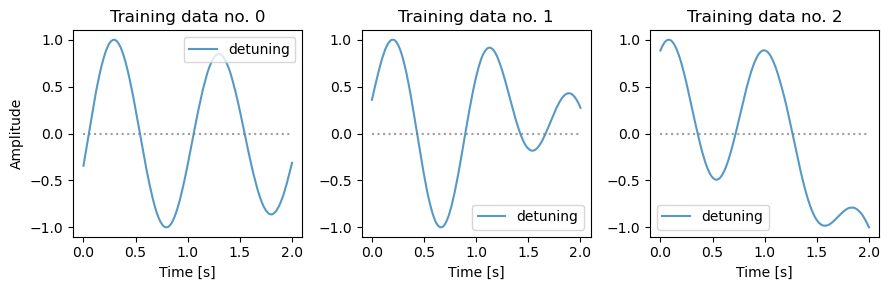

In [5]:
# --!------------------------------------------------------!
# --! display mixed datasets

datadir               = '../../data/kalman/train_sim_mix'
timeseries_ndim       = 1
timeseries_nsample    = 200
timestep              = 0.01

# --! subtimeseries give us additional flexibility by allowing to work with subportions
# --! of original sampled timeseries
subtimeseries_nsample = timeseries_nsample

utils_plot.plot_dataset(datadir, timeseries_nsample, timestep)

### KIND model instantiation

In [6]:
# --!--------------------------------------------------------------------------
# --! instantiate a model

# --! ensure reproducible results
seed = 12
torch.manual_seed(seed)

model_cfg = kind.model_config(

    timeseries_ndim    = timeseries_ndim,
    timeseries_nsample = subtimeseries_nsample, # by using subtimeseries we may work with fewer samples than originally sampled
    timestep           = timestep,

    fun = {
        'data1'  : 1,
        'data2'  : 1,
        'data3'  : 1,
        'data4'  : 1,
        'sin'    : 2,
        'cos'    : 2
    },

    param_kernsize = 20
)

model = kind.model(model_cfg)

### KIND model training

In [7]:
# --!--------------------------------------------------------------------------
# --! train all phases in one loop

# --! number of timeseries in one batch
batsize = 128

trainparam = {
    'stadatadir'            : '../../data/kalman/train_sim_sta',
    'transdatadir'          : '../../data/kalman/train_sim_dyn',
    'mixdatadir'            : '../../data/kalman/train_sim_mix',
    'timeseries_nsample'    : timeseries_nsample,
    'subtimeseries_nsample' : subtimeseries_nsample,
    'train_nfile'           : 7,
    'batsize'               : batsize,
    'nepoch'                : 100,
    'isverbose'             : True,
    'learnrate'             : 1e-3,
    'weightdecay'           : 1e-4,
}

loss = []

while True:
    loss.append(model.fit(trainparam))
    if not model.fit_next():
        break

inf >> fit: entering stationary mean phase
inf >> number of data files for training is 7
inf >> processing training file number 1
inf >> processing training file number 2
inf >> processing training file number 3
inf >> processing training file number 4
inf >> processing training file number 5
inf >> processing training file number 6
inf >> processing training file number 7
inf >> fit: entering stationary variance phase
inf >> number of data files for training is 7
inf >> processing training file number 1
inf >> processing training file number 2
inf >> processing training file number 3
inf >> processing training file number 4
inf >> processing training file number 5
inf >> processing training file number 6
inf >> processing training file number 7
inf >> fit: entering dynamic mean phase
inf >> number of data files for training is 7
inf >> processing training file number 1
inf >> processing training file number 2
inf >> processing training file number 3
inf >> processing training file num

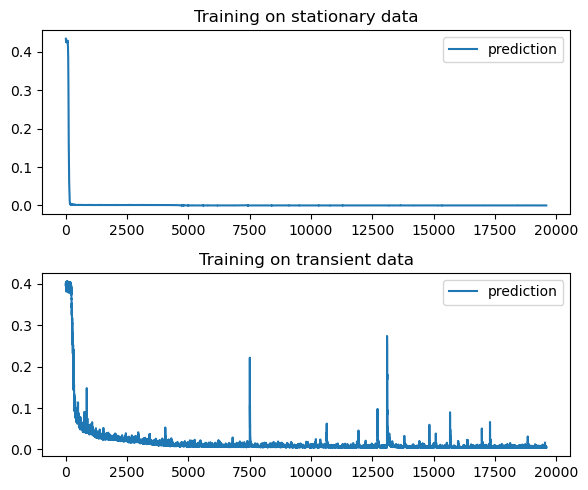

In [8]:
# --!--------------------------------------------------------------------------
# --! plot training statistics

with torch.no_grad():
    sta_stats = loss[0]
    dyn_stats = loss[2]

    plt.figure(figsize=(6, 5))

    plt.subplot(2, 1, 1)
    plt.title('Training on stationary data')
    plt.plot(sta_stats[0], label='prediction')
    plt.legend()

    plt.subplot(2, 1, 2)
    plt.title('Training on transient data')
    plt.plot(dyn_stats[0], label='prediction')
    plt.legend()

    plt.tight_layout()
    plt.show()

In [9]:
# --!--------------------------------------------------------------------------
# --! save a trained global model

savemod_on = True
print(model.operator_sta.model.weight)

if savemod_on:
    torch.save(model, '../../models/kalman/kind_sim.pt')

Parameter containing:
tensor([[ 0.3859,  1.0103, -0.4837,  0.3669,  0.3343,  0.5789],
        [-0.2640,  0.2932,  0.1916, -0.3310, -0.0111, -0.1860],
        [ 0.4292, -0.2849,  0.1625,  0.0953,  0.0412,  0.3173],
        [-0.6550,  0.3963, -0.1505,  0.1877, -0.0652, -0.4164],
        [ 0.0944,  0.1914, -0.1196, -0.1115,  0.0529,  0.1326],
        [ 0.6708,  0.5644, -0.1374, -0.0759,  0.2745,  0.5896]])
